In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from scipy.stats import vonmises
from scipy.special import i0
from math import sin
from math import cos
import json
from IPython.display import display


# run functions

### def wrap_angle_rad

功能：把任意弧度角限制到 $[-\pi, \pi)$，用于计算圆周角度差。

输入：`theta`，标量或数组形式的弧度角。

输出：与输入形状相同的圆周范围内角度。


In [2]:
def wrap_angle_rad(theta):
    wrap = (theta + np.pi) % (2 * np.pi) - np.pi
    return wrap


### def compute_log_likelihood

功能：使用给定的初始状态概率、转移矩阵和 emission 参数，计算一段连续 trial 序列的对数似然。

输入：`data`、`params`、`transition_matrix`、`initial_probabilities`。

输出：该 trial 序列的 `log_likelihood`。


In [3]:
def compute_log_likelihood(
    data,
    params,
    transition_matrix,
    initial_probabilities,
):
    """
    Compute the log-likelihood of one continuous trial sequence.

    Parameters
    ----------
    data : dict
        Must contain:
        - x_rad
        - y_rad
        - coherence
        - prior_std

    params : dict
        Must contain:
        - kappaS: dict mapping coherence to sensory kappa
        - kappaP: dict mapping prior_std to prior kappa

    transition_matrix : array, shape (3, 3)
        Rows are previous states and columns are next states.

    initial_probabilities : array, shape (3,)
        Initial probabilities for Sensory, Prior, and Lapse states.

    Returns
    -------
    log_likelihood : float
        Log-likelihood of this one trial sequence.
    """

    x_rad = np.asarray(data["x_rad"], dtype=float)
    y_rad = np.asarray(data["y_rad"], dtype=float)
    coherence = np.asarray(data["coherence"])
    prior_std = np.asarray(data["prior_std"])

    transition_matrix = np.asarray(
        transition_matrix,
        dtype=float,
    )

    initial_probabilities = np.asarray(
        initial_probabilities,
        dtype=float,
    )

    n_trials = len(y_rad)

    if n_trials == 0:
        raise ValueError("The input data contains no trials.")

    if not (
        len(x_rad)
        == len(y_rad)
        == len(coherence)
        == len(prior_std)
    ):
        raise ValueError("All trial-level arrays must have the same length.")

    if transition_matrix.shape != (3, 3):
        raise ValueError("transition_matrix must have shape (3, 3).")

    if initial_probabilities.shape != (3,):
        raise ValueError("initial_probabilities must have shape (3,).")

    transition_matrix = (
        transition_matrix
        / transition_matrix.sum(axis=1, keepdims=True)
    )

    initial_probabilities = (
        initial_probabilities
        / initial_probabilities.sum()
    )

    emission_matrix = np.zeros((n_trials, 3))

    for t in range(n_trials):

        kappaS_t = params["kappaS"][coherence[t]]
        kappaP_t = params["kappaP"][prior_std[t]]

        sensory_likelihood = vonmises.pdf(
            y_rad[t],
            kappaS_t,
            loc=x_rad[t],
        )

        prior_likelihood = vonmises.pdf(
            y_rad[t],
            kappaP_t,
            loc=0.0,
        )

        lapse_likelihood = 1.0 / (2.0 * np.pi)

        emission_matrix[t] = [
            sensory_likelihood,
            prior_likelihood,
            lapse_likelihood,
        ]

    # Trial 1
    alpha = initial_probabilities * emission_matrix[0]

    scale = alpha.sum()

    if scale <= 0 or not np.isfinite(scale):
        return -np.inf

    alpha = alpha / scale
    log_likelihood = np.log(scale)

    # Trial 2 to Trial T
    for t in range(1, n_trials):

        predicted_probabilities = alpha @ transition_matrix

        alpha = (
            predicted_probabilities
            * emission_matrix[t]
        )

        scale = alpha.sum()

        if scale <= 0 or not np.isfinite(scale):
            return -np.inf

        alpha = alpha / scale
        log_likelihood += np.log(scale)

    return float(log_likelihood)

### def prepare_hmm_data

功能：把原始运动方向和反应坐标转换成以 prior mean 为中心的弧度数据，并整理 HMM 所需变量。

输入：运动方向、反应坐标、prior mean、prior std、coherence、subject id 和 run id。

输出：包含 `x_rad`、`y_rad`、`coherence`、`prior_std`、`block_id` 和 `subject_id` 的字典。


In [4]:
def prepare_hmm_data(
        motion_direction,
        estimate_x,
        estimate_y,
        prior_mean,
        prior_std,
        motion_coherence,
        subject_id,
        run_id,
):
    esti_agl = np.atan2(estimate_y, estimate_x)

    motion_rad = np.deg2rad(motion_direction)
    prior_mean_rad = np.deg2rad(prior_mean)

    x_rad = wrap_angle_rad(motion_rad - prior_mean_rad)
    y_rad = wrap_angle_rad(esti_agl - prior_mean_rad)

    block_id = run_id

    data = {
        "x_rad": x_rad,
        "y_rad": y_rad,
        "coherence": motion_coherence,
        "prior_std": prior_std,
        "block_id": block_id,
        "subject_id": subject_id,
    }

    return data


## initialize functions

### def initialize_parameters

功能：给 Soft EM-HMM 提供初始状态概率、初始转移矩阵和各实验条件下的初始 kappa。

输入：无。

输出：参数字典 `params`。


In [5]:
def initialize_parameters():
    params = {
        "initial_prob": np.array([0.60, 0.35, 0.05]),

        "transition_matrix": np.array([
            [0.80, 0.15, 0.05],
            [0.15, 0.80, 0.05],
            [0.40, 0.40, 0.20],
        ]),

        "kappaS": {
            0.06: 1.5,
            0.12: 4.5,
            0.24: 20.0,
        },

        "kappaP": {
            80: 0.5,
            40: 1.0,
            20: 6.0,
            10: 30.0,
        },
    }

    return params


## Emission function

### def von_mises_density

功能：计算观察角度在指定 von Mises 分布下的概率密度。

输入：观察角度 `theta`、分布中心 `mu` 和集中参数 `kappa`。

输出：von Mises 概率密度。


In [6]:
def von_mises_density(theta, mu, kappa):
    p = np.exp(kappa * np.cos(theta - mu)) / (2 * np.pi * i0(kappa))
    return p


### def get_sensory_kappa

功能：根据当前 trial 的 coherence 取得对应的 sensory kappa。

输入：sensory kappa 字典 `kappaS` 和当前 `coherence`。

输出：当前条件对应的 sensory kappa。


In [7]:
def get_sensory_kappa(kappaS, coherence):
    return kappaS[coherence]


### def get_prior_kappa

功能：根据当前 trial 的 prior std 取得对应的 prior kappa。

输入：prior kappa 字典 `kappaP` 和当前 `prior_std`。

输出：当前条件对应的 prior kappa。


In [8]:
def get_prior_kappa(kappaP, prior_std):
    return kappaP[prior_std]


### def compute_trial_emission_likelihoods

功能：计算一个 trial 在 Sensory、Prior 和 Lapse 三个状态下的 emission likelihood。

输入：当前 response `y_t`、stimulus `x_t`、coherence、prior std 和参数字典。

输出：按 `[Sensory, Prior, Lapse]` 排列的三个 likelihood。


In [9]:
def compute_trial_emission_likelihoods(y_t, x_t, coherence, prior_std, params):
    bS = von_mises_density(
        y_t,
        x_t,
        get_sensory_kappa(params["kappaS"], coherence),
    )
    bP = von_mises_density(
        y_t,
        0.0,
        get_prior_kappa(params["kappaP"], prior_std),
    )
    bL = 1 / (2 * np.pi)

    return np.array([bS, bP, bL])


### def compute_emission_matrix

功能：逐 trial 调用 emission 函数，生成整段数据的 emission matrix。

输入：整理后的 `data` 和参数字典 `params`。

输出：形状为 `n_trials × 3` 的 emission matrix。


In [10]:
def compute_emission_matrix(data, params):
    x_rad = data["x_rad"]
    y_rad = data["y_rad"]
    coherence = data["coherence"]
    prior_std = data["prior_std"]

    n_trials = len(x_rad)
    emission_matrix = np.zeros((n_trials, 3))

    for t in range(n_trials):
        emission_matrix[t] = compute_trial_emission_likelihoods(
            y_t=y_rad[t],
            x_t=x_rad[t],
            coherence=coherence[t],
            prior_std=prior_std[t],
            params=params,
        )

    return emission_matrix


## Forward-Backward function

### def forward_pass

功能：从前向后结合初始概率、转移矩阵和当前 emission，计算每个 trial 的预测概率、过滤后概率及序列对数似然。

输入：参数字典 `params` 和一段连续 block 数据 `data`。

输出：`predicted_prob`、`filtered_prob`、`emission_likelihood`、`scales` 和 `log_likelihood`。


In [11]:
def forward_pass(params, data):
    x_rad = data["x_rad"]
    y_rad = data["y_rad"]
    coherence = data["coherence"]
    prior_std = data["prior_std"]

    n = len(x_rad)
    n_states = 3

    A = params["transition_matrix"]
    initial_probs = params["initial_prob"]

    predicted_prob = np.zeros((n, n_states))
    filtered_prob = np.zeros((n, n_states))
    emission_likelihood = np.zeros((n, n_states))
    scales = np.zeros(n)

    log_likelihood = 0.0

    # Prior state probability before observing trial 0
    predicted_prob[0] = initial_probs

    for i in range(n):
        emission_likelihood[i] = compute_trial_emission_likelihoods(
            y_t=y_rad[i],
            x_t=x_rad[i],
            coherence=coherence[i],
            prior_std=prior_std[i],
            params=params,
        )

        filtered_unnormalized = (
            predicted_prob[i]
            * emission_likelihood[i]
        )

        scales[i] = filtered_unnormalized.sum()

        if scales[i] <= 0:
            raise ValueError(
                f"Forward scaling factor is zero at trial {i}."
            )

        filtered_prob[i] = (
            filtered_unnormalized / scales[i]
        )

        log_likelihood += np.log(scales[i])

        if i < n - 1:
            predicted_prob[i + 1] = (
                filtered_prob[i] @ A
            )

    return (
        predicted_prob,
        filtered_prob,
        emission_likelihood,
        scales,
        log_likelihood,
    )


### def backward_pass

功能：从最后一个 trial 向前计算未来数据对当前隐藏状态的支持。

输入：`params`、连续 block 数据、forward scaling factors 和 emission likelihood。

输出：每个 trial、每个状态的 backward probability `beta`。


In [12]:
def backward_pass(params, data, scales, emission_likelihood):
    x_rad = data["x_rad"]

    n = len(x_rad)
    n_states = 3

    beta = np.zeros((n, n_states))
    A = params["transition_matrix"]

    beta[-1] = [1.0, 1.0, 1.0]

    for t in range(n - 2, -1, -1):
        future_support_next = (
            emission_likelihood[t + 1]
            * beta[t + 1]
        )

        beta[t] = A @ future_support_next
        beta[t] /= scales[t + 1]

    return beta

## M-step update

### def update_state_posteriors

功能：结合 forward 过滤概率和 backward probability，计算每个 trial 的状态后验概率 gamma。

输入：`filtered_prob` 和 `beta`。

输出：形状为 `n_trials × 3` 的 `gamma`。


In [13]:
def update_state_posteriors(filtered_porb, beta):
    gamma_unnormalized = filtered_porb * beta
    gamma = gamma_unnormalized / gamma_unnormalized.sum(
        axis=1,
        keepdims=True
    )
    return gamma

### def compute_transition_posteriors

功能：计算每一对相邻 trial 在九种状态转移下的联合后验概率 xi。

输入：过滤后状态概率、`beta`、emission likelihood 和 transition matrix。

输出：形状为 `(n_trials - 1) × 3 × 3` 的 `xi`。


In [14]:
def compute_transition_posteriors(
        filtered_prob,
        beta,
        emission_likelihood,
        transition_matrix,
):
    next_state_support = (
        emission_likelihood[1:] * beta[1:]
    )

    xi_unnormalized = (
        filtered_prob[:-1, :, np.newaxis]
        * transition_matrix[np.newaxis, :, :]
        * next_state_support[:, np.newaxis, :]
    )

    normalizers = xi_unnormalized.sum(
        axis=(1, 2),
        keepdims=True,
    )

    if np.any(normalizers <= 0):
        raise ValueError(
            "Some transition posteriors cannot be normalized."
        )

    xi = xi_unnormalized / normalizers

    return xi

### def compute_weighted_resultant_length

功能：使用状态后验概率作为权重，计算圆周误差的加权 resultant length。

输入：圆周误差 `error` 和对应权重 `weights`。

输出：范围通常在 0 到 1 之间的 resultant length `R`。


In [15]:
def compute_weighted_resultant_length(error, weights):
    weighted_cos = np.sum(weights * np.cos(error))
    weighted_sin = np.sum(weights * np.sin(error))

    R = np.sqrt(
        weighted_cos**2 + weighted_sin**2
    ) / np.sum(weights)

    return R

### def estimate_kappa_from_resultant

功能：根据 resultant length 的常用分段近似，估计 von Mises 分布的 kappa。

输入：resultant length `R`。

输出：估计得到的 `kappa`。


In [16]:
def estimate_kappa_from_resultant(R):
    R = np.clip(R, 0.0, 0.999999)

    if R < 0.53:
        kappa = 2 * R + R**3 + 5 * R**5 / 6

    elif R < 0.85:
        kappa = -0.4 + 1.39 * R + 0.43 / (1 - R)

    else:
        kappa = 1 / (R**3 - 4 * R**2 + 3 * R)

    return kappa

### def update_sensory_kappas

功能：按 coherence 条件，用 Sensory 状态后验概率加权 sensory error，更新各 sensory kappa。

输入：`data`、状态后验 `gamma` 和当前 `params`。

输出：更新后的 sensory kappa 字典。


In [17]:
def update_sensory_kappas(data, gamma, params):
    x_rad = data["x_rad"]
    y_rad = data["y_rad"]
    coherence = data["coherence"]

    error_S = wrap_angle_rad(y_rad - x_rad)
    weights_S = gamma[:, 0]

    new_kappaS = {}

    for condition in params["kappaS"].keys():
        mask = coherence == condition

        condition_errors = error_S[mask]
        condition_weights = weights_S[mask]

        R = compute_weighted_resultant_length(
            condition_errors,
            condition_weights,
        )

        new_kappaS[condition] = (
            estimate_kappa_from_resultant(R)
        )

    return new_kappaS

### def update_prior_kappas

功能：按 prior std 条件，用 Prior 状态后验概率加权 prior error，更新各 prior kappa。

输入：`data`、状态后验 `gamma` 和当前 `params`。

输出：更新后的 prior kappa 字典。


In [18]:
def update_prior_kappas(data, gamma, params):
    y_rad = data["y_rad"]
    prior_std = data["prior_std"]

    error_P = wrap_angle_rad(y_rad)
    weights_P = gamma[:, 1]

    new_kappaP = {}

    for condition in params["kappaP"].keys():
        mask = prior_std == condition

        condition_errors = error_P[mask]
        condition_weights = weights_P[mask]

        R = compute_weighted_resultant_length(
            condition_errors,
            condition_weights,
        )

        new_kappaP[condition] = (
            estimate_kappa_from_resultant(R)
        )

    return new_kappaP

### def update_emission_parameters

功能：根据 `update_kappa` 设置，统一更新 sensory 和 prior emission 参数。

输入：`data`、`gamma`、当前 `params` 和 `update_kappa`。

输出：更新后的参数字典。


In [19]:
def update_emission_parameters(data, gamma, params, update_kappa=True):
    if update_kappa:
        params["kappaS"] = update_sensory_kappas(
            data,
            gamma,
            params,
        )

        params["kappaP"] = update_prior_kappas(
            data,
            gamma,
            params,
        )

    return params

### def update_transition_matrix

功能：把所有相邻 trial 的 xi 作为 soft transition counts，逐行归一化得到新的 transition matrix。

输入：`xi` 和可选平滑量 `smoothing`。

输出：形状为 `3 × 3` 的新 transition matrix。


In [20]:
def update_transition_matrix(xi, smoothing=1e-6):
    transition_counts = xi.sum(axis=0)
    transition_counts = transition_counts + smoothing

    transition_matrix = transition_counts / transition_counts.sum(
        axis=1,
        keepdims=True,
    )

    return transition_matrix


### def update_initial_probabilities

功能：对每个独立 block 的首个 trial 后验取平均，并归一化为新的初始状态概率。

输入：各 block 首 trial 的 `gamma` 和可选平滑量。

输出：形状为 3 的初始状态概率。


In [21]:
def update_initial_probabilities(block_initial_gammas, smoothing=1e-6):
    initial_counts = np.asarray(block_initial_gammas, dtype=float).sum(axis=0)
    initial_counts = initial_counts + smoothing
    return initial_counts / initial_counts.sum()


### def m_step

功能：完成一次 M-step，使用 xi 更新 transition matrix，并可选地使用 gamma 更新 kappa。

输入：`data`、`gamma`、`xi`、当前 `params` 和 `update_kappa`。

输出：更新后的参数字典 `new_params`。


In [22]:
def m_step(
        data,
        gamma,
        xi,
        params,
        update_kappa=True,
        update_pi=True,
        block_initial_gammas=None,
        transition_smoothing=1e-6,
):
    new_params = {
        "initial_prob": params["initial_prob"].copy(),
        "transition_matrix": params["transition_matrix"].copy(),
        "kappaS": params["kappaS"].copy(),
        "kappaP": params["kappaP"].copy(),
    }

    new_params["transition_matrix"] = update_transition_matrix(
        xi,
        smoothing=transition_smoothing,
    )

    if update_pi:
        new_params["initial_prob"] = update_initial_probabilities(
            block_initial_gammas,
            smoothing=transition_smoothing,
        )

    if update_kappa:
        new_params["kappaS"] = update_sensory_kappas(data, gamma, params)
        new_params["kappaP"] = update_prior_kappas(data, gamma, params)

    return new_params


# full-training function

### def compute_total_log_likelihood

功能：把所有 block 的 log-likelihood 相加，得到当前 EM 迭代的总对数似然。

输入：每个 block 的 `block_log_likelihoods`。

输出：总对数似然。


In [23]:
def compute_total_log_likelihood(block_log_likelihoods):
    total_log_likelihood = np.sum(block_log_likelihoods)
    return float(total_log_likelihood)


### def check_convergence

功能：比较相邻两轮总 log-likelihood，判断 Soft EM 是否达到停止条件。

输入：当前和上一轮 log-likelihood，以及阈值 `tol`。

输出：布尔值，达到阈值时为 `True`。


In [24]:
def check_convergence(
        current_log_likelihood,
        previous_log_likelihood,
        tol=1e-6,
):
    if previous_log_likelihood is None:
        return False

    difference = abs(
        current_log_likelihood - previous_log_likelihood
    )

    return difference < tol


### def fit_soft_em_hmm

功能：按 block 重复执行 emission、forward-backward 和 M-step，直到收敛或达到最大迭代次数。

输入：完整 `data`、可选初始 `params`、`update_kappa`、`max_iter` 和 `tol`。

输出：最终参数、每个 trial 的 gamma、每对相邻 trial 的 xi、log-likelihood 历史和收敛信息。


In [25]:
def fit_soft_em_hmm(
        data,
        params=None,
        update_kappa=True,
        update_pi=True,
        transition_smoothing=1e-6,
        max_iter=100,
        tol=1e-6,
):
    if params is None:
        params = initialize_parameters()

    current_params = {
        "initial_prob": params["initial_prob"].copy(),
        "transition_matrix": params["transition_matrix"].copy(),
        "kappaS": params["kappaS"].copy(),
        "kappaP": params["kappaP"].copy(),
    }

    block_ids = np.asarray(data["block_id"])
    unique_blocks = pd.unique(block_ids)
    log_likelihood_history = []
    previous_log_likelihood = None
    converged = False
    final_gamma = None
    final_xi = None

    for iteration in range(max_iter):
        gamma_list = []
        xi_list = []
        block_initial_gammas = []
        block_log_likelihoods = []
        combined_data = {"x_rad": [], "y_rad": [], "coherence": [], "prior_std": []}

        for block in unique_blocks:
            mask = block_ids == block
            block_data = {
                "x_rad": np.asarray(data["x_rad"])[mask],
                "y_rad": np.asarray(data["y_rad"])[mask],
                "coherence": np.asarray(data["coherence"])[mask],
                "prior_std": np.asarray(data["prior_std"])[mask],
            }
            (
                predicted_prob,
                filtered_prob,
                emission_likelihood,
                scales,
                block_log_likelihood,
            ) = forward_pass(current_params, block_data)
            beta = backward_pass(current_params, block_data, scales, emission_likelihood)
            gamma = update_state_posteriors(filtered_prob, beta)
            xi = compute_transition_posteriors(
                filtered_prob,
                beta,
                emission_likelihood,
                current_params["transition_matrix"],
            )
            gamma_list.append(gamma)
            xi_list.append(xi)
            block_initial_gammas.append(gamma[0])
            block_log_likelihoods.append(block_log_likelihood)
            for key in combined_data:
                combined_data[key].append(block_data[key])

        gamma_all = np.concatenate(gamma_list, axis=0)
        xi_all = np.concatenate(xi_list, axis=0)
        combined_data = {
            key: np.concatenate(value, axis=0)
            for key, value in combined_data.items()
        }
        total_log_likelihood = compute_total_log_likelihood(block_log_likelihoods)
        log_likelihood_history.append(total_log_likelihood)
        converged = check_convergence(total_log_likelihood, previous_log_likelihood, tol)
        final_gamma = gamma_all
        final_xi = xi_all

        if converged or iteration == max_iter - 1:
            break

        current_params = m_step(
            combined_data,
            gamma_all,
            xi_all,
            current_params,
            update_kappa=update_kappa,
            update_pi=update_pi,
            block_initial_gammas=block_initial_gammas,
            transition_smoothing=transition_smoothing,
        )
        previous_log_likelihood = total_log_likelihood

    return {
        "params": current_params,
        "gamma": final_gamma,
        "xi": final_xi,
        "log_likelihood_history": log_likelihood_history,
        "converged": converged,
        "n_iterations": len(log_likelihood_history),
    }


# Viterbi-decoding function

### def viterbi_decode_block

功能：使用训练完成的参数，对一个连续 block 解码最可能的完整隐藏状态路径。

输入：一个 block 的 `data` 和训练后的 `params`。

输出：按 trial 排列的状态编号路径，0、1、2 分别对应 Sensory、Prior、Lapse。


In [26]:
def viterbi_decode_block(data, params):
    emission_matrix = compute_emission_matrix(data, params)

    n_trials = len(data["x_rad"])
    n_states = 3

    log_initial = np.log(params["initial_prob"])
    log_transition = np.log(params["transition_matrix"])
    log_emission = np.log(emission_matrix)

    delta = np.zeros((n_trials, n_states))
    psi = np.zeros((n_trials, n_states), dtype=int)

    delta[0] = log_initial + log_emission[0]

    for t in range(1, n_trials):
        for current_state in range(n_states):
            previous_scores = (
                delta[t - 1]
                + log_transition[:, current_state]
            )

            psi[t, current_state] = np.argmax(previous_scores)
            delta[t, current_state] = (
                previous_scores[psi[t, current_state]]
                + log_emission[t, current_state]
            )

    state_path = np.zeros(n_trials, dtype=int)
    state_path[-1] = np.argmax(delta[-1])

    for t in range(n_trials - 2, -1, -1):
        state_path[t] = psi[t + 1, state_path[t + 1]]

    return state_path


### def viterbi_decode_all_blocks

功能：对完整数据中的每个 block 分别运行 Viterbi，避免跨 block 连接状态路径。

输入：完整 `data` 和训练后的 `params`。

输出：与原 trial 顺序一致的 Viterbi 状态编号数组。


In [27]:
def viterbi_decode_all_blocks(data, params):
    block_ids = np.asarray(data["block_id"])
    unique_blocks = pd.unique(block_ids)

    all_state_paths = np.zeros(len(block_ids), dtype=int)

    for block in unique_blocks:
        mask = block_ids == block

        block_data = {
            "x_rad": np.asarray(data["x_rad"])[mask],
            "y_rad": np.asarray(data["y_rad"])[mask],
            "coherence": np.asarray(data["coherence"])[mask],
            "prior_std": np.asarray(data["prior_std"])[mask],
        }

        block_state_path = viterbi_decode_block(
            block_data,
            params,
        )

        all_state_paths[mask] = block_state_path

    return all_state_paths


# Soft EM-HMM 诊断、最小修正与全被试重跑

本节先诊断 Subject 2 的 likelihood 下降来源，再验证缺失 response trial 的序列断点规则，最后使用统一修正版重新运行全部 12 名被试。原 notebook、CSV、PDF 和原结果目录均不修改。


## Cell A：统一设置与数据读取

沿用已验证的初值、smoothing、`tol=1e-6` 和 `max_iter=300`。实质性 likelihood 下降阈值固定为 `1e-8`；kappa 数值优化范围为 `(1e-6, 500)`，该范围仅保证数值稳定，不改变 emission family。


In [28]:
from scipy.optimize import minimize_scalar
from scipy.special import i0e

base_max_iter = 300
tol = 1e-6
transition_smoothing = 1e-6
update_pi = True
random_seed = 20260717
likelihood_drop_tolerance = 1e-8
kappa_lower_bound = 1e-6
kappa_upper_bound = 500.0
np.random.seed(random_seed)

training_settings = {
    "max_iter": base_max_iter,
    "tol": tol,
    "transition_smoothing": transition_smoothing,
    "update_pi": update_pi,
    "update_kappa": True,
    "random_seed": random_seed,
    "initial_pi": [0.60, 0.35, 0.05],
    "initial_transition_matrix": [
        [0.80, 0.15, 0.05],
        [0.15, 0.80, 0.05],
        [0.40, 0.40, 0.20],
    ],
    "initial_sensory_kappas": {"0.06": 1.5, "0.12": 4.5, "0.24": 20.0},
    "initial_prior_kappas": {"80": 0.5, "40": 1.0, "20": 6.0, "10": 30.0},
    "likelihood_drop_tolerance": likelihood_drop_tolerance,
    "kappa_lower_bound": kappa_lower_bound,
    "kappa_upper_bound": kappa_upper_bound,
}

prepared_data = pd.read_csv("../data/data01_direction4priors.csv")
prepared_data["_original_row_index"] = np.arange(len(prepared_data))
subject_ids = sorted(prepared_data["subject_id"].unique())
output_root = Path("../results")
output_root.mkdir(exist_ok=True)
print(f"读取 {len(prepared_data)} trials，{len(subject_ids)} 名被试。")


读取 83213 trials，12 名被试。


## Cell B：缺失 trial 分段函数

`split_blocks_at_missing_trials` 删除 `estimate_x` 或 `estimate_y` 缺失的 trial，并把缺失位置视为序列断点。只有包含缺失值且缺失后仍有有效 trial 的原 block 才会增加 segment；没有缺失的 block 保持原 block id 和顺序。


In [29]:
def split_blocks_at_missing_trials(subject_df):
    subject_df = subject_df.sort_values(
        ["subject_id", "session_id", "run_id", "trial_index"],
        kind="stable",
    ).reset_index(drop=True)
    cleaned_rows = []
    missing_rows = []

    for (session_id, run_id), block_df in subject_df.groupby(
        ["session_id", "run_id"], sort=False
    ):
        block_df = block_df.sort_values("trial_index", kind="stable").reset_index(drop=True)
        missing_mask = block_df[["estimate_x", "estimate_y"]].isna().any(axis=1)
        base_block_id = f"{int(session_id)}_{int(run_id)}"

        if not missing_mask.any():
            for _, row in block_df.iterrows():
                row_copy = row.copy()
                row_copy["block_id"] = base_block_id
                cleaned_rows.append(row_copy)
            continue

        segment_number = 1
        valid_seen = False
        break_pending = False
        valid_positions = np.flatnonzero(~missing_mask.to_numpy())

        for position, row in block_df.iterrows():
            if missing_mask.iloc[position]:
                previous_positions = valid_positions[valid_positions < position]
                following_positions = valid_positions[valid_positions > position]
                missing_rows.append({
                    "subject_id": int(row["subject_id"]),
                    "session_id": int(session_id),
                    "run_id": int(run_id),
                    "trial_index": int(row["trial_index"]),
                    "original_row_index": int(row["_original_row_index"]),
                    "original_block_id": base_block_id,
                    "estimate_x_missing": bool(pd.isna(row["estimate_x"])),
                    "estimate_y_missing": bool(pd.isna(row["estimate_y"])),
                    "preceding_valid_trial_index": (
                        int(block_df.iloc[previous_positions[-1]]["trial_index"])
                        if len(previous_positions) else np.nan
                    ),
                    "following_valid_trial_index": (
                        int(block_df.iloc[following_positions[0]]["trial_index"])
                        if len(following_positions) else np.nan
                    ),
                })
                break_pending = True
                continue

            if break_pending and valid_seen:
                segment_number += 1
            break_pending = False
            valid_seen = True
            row_copy = row.copy()
            row_copy["block_id"] = f"{base_block_id}_segment_{segment_number:02d}"
            cleaned_rows.append(row_copy)

    cleaned_data = pd.DataFrame(cleaned_rows).reset_index(drop=True)
    missing_trial_report = pd.DataFrame(missing_rows, columns=[
        "subject_id", "session_id", "run_id", "trial_index",
        "original_row_index", "original_block_id", "estimate_x_missing",
        "estimate_y_missing", "preceding_valid_trial_index",
        "following_valid_trial_index",
    ])
    return cleaned_data, missing_trial_report


## Cell C：统一数据和参数辅助函数

这些简单函数构造每名被试的 segment-level HMM 数据、复制参数，并用同一组完整参数按独立 segment 计算 observed-data log-likelihood。


In [30]:
def make_initial_params(settings):
    return {
        "initial_prob": np.asarray(settings["initial_pi"], dtype=float).copy(),
        "transition_matrix": np.asarray(
            settings["initial_transition_matrix"], dtype=float
        ).copy(),
        "kappaS": {
            float(key): float(value)
            for key, value in settings["initial_sensory_kappas"].items()
        },
        "kappaP": {
            int(key): float(value)
            for key, value in settings["initial_prior_kappas"].items()
        },
    }


def copy_params(params):
    return {
        "initial_prob": np.asarray(params["initial_prob"], dtype=float).copy(),
        "transition_matrix": np.asarray(params["transition_matrix"], dtype=float).copy(),
        "kappaS": params["kappaS"].copy(),
        "kappaP": params["kappaP"].copy(),
    }


def prepare_subject_segments(subject_id, prepared_data):
    subject_df = prepared_data.loc[prepared_data["subject_id"] == subject_id].copy()
    if subject_df.empty:
        raise ValueError(f"Subject {subject_id} 没有 trial。")
    cleaned_df, missing_report = split_blocks_at_missing_trials(subject_df)
    if cleaned_df.empty:
        raise ValueError(f"Subject {subject_id} 删除缺失 response 后没有有效 trial。")
    subject_data = prepare_hmm_data(
        motion_direction=cleaned_df["motion_direction"].to_numpy(),
        estimate_x=cleaned_df["estimate_x"].to_numpy(),
        estimate_y=cleaned_df["estimate_y"].to_numpy(),
        prior_mean=cleaned_df["prior_mean"].to_numpy(),
        prior_std=cleaned_df["prior_std"].to_numpy(),
        motion_coherence=cleaned_df["motion_coherence"].to_numpy(),
        subject_id=cleaned_df["subject_id"].to_numpy(),
        run_id=cleaned_df["block_id"].to_numpy(),
    )
    return cleaned_df, subject_data, missing_report


def evaluate_total_log_likelihood(data, params):
    block_ids = np.asarray(data["block_id"])
    block_likelihoods = []
    for block_id in pd.unique(block_ids):
        mask = block_ids == block_id
        block_data = {
            "x_rad": np.asarray(data["x_rad"])[mask],
            "y_rad": np.asarray(data["y_rad"])[mask],
            "coherence": np.asarray(data["coherence"])[mask],
            "prior_std": np.asarray(data["prior_std"])[mask],
        }
        *_, block_ll = forward_pass(params, block_data)
        block_likelihoods.append(block_ll)
    return compute_total_log_likelihood(block_likelihoods)


## Cell D：E-step 与严格 kappa 更新

原 sensory/prior 均使用固定均值，因此 kappa 的 expected log-likelihood 只依赖加权 `cos(error)`；原近似使用包含 sine 项的 resultant length，相当于同时允许均值自由变化，并不保证最大化当前固定均值模型的 Q 函数。修正版对每个条件直接进行一维有界优化。


In [31]:
def expectation_step(params, data):
    block_ids = np.asarray(data["block_id"])
    gamma_list = []
    xi_list = []
    block_initial_gammas = []
    block_likelihoods = []
    combined_data = {"x_rad": [], "y_rad": [], "coherence": [], "prior_std": []}

    for block_id in pd.unique(block_ids):
        mask = block_ids == block_id
        block_data = {
            "x_rad": np.asarray(data["x_rad"])[mask],
            "y_rad": np.asarray(data["y_rad"])[mask],
            "coherence": np.asarray(data["coherence"])[mask],
            "prior_std": np.asarray(data["prior_std"])[mask],
        }
        (
            predicted_prob,
            filtered_prob,
            emission_likelihood,
            scales,
            block_likelihood,
        ) = forward_pass(params, block_data)
        beta = backward_pass(params, block_data, scales, emission_likelihood)
        gamma = update_state_posteriors(filtered_prob, beta)
        if len(block_data["x_rad"]) > 1:
            xi = compute_transition_posteriors(
                filtered_prob,
                beta,
                emission_likelihood,
                params["transition_matrix"],
            )
            xi_list.append(xi)
        gamma_list.append(gamma)
        block_initial_gammas.append(gamma[0])
        block_likelihoods.append(block_likelihood)
        for key in combined_data:
            combined_data[key].append(block_data[key])

    gamma_all = np.concatenate(gamma_list, axis=0)
    xi_all = np.concatenate(xi_list, axis=0)
    combined_data = {
        key: np.concatenate(values, axis=0)
        for key, values in combined_data.items()
    }
    return {
        "gamma": gamma_all,
        "xi": xi_all,
        "block_initial_gammas": np.asarray(block_initial_gammas),
        "combined_data": combined_data,
        "log_likelihood": compute_total_log_likelihood(block_likelihoods),
    }


def optimize_fixed_mean_kappa(errors, weights, old_kappa, lower, upper):
    errors = np.asarray(errors, dtype=float)
    weights = np.asarray(weights, dtype=float)
    weight_sum = float(weights.sum())
    if weight_sum <= 1e-12:
        return float(old_kappa)
    weighted_cosine = float(np.sum(weights * np.cos(errors)))

    def negative_expected_log_likelihood(kappa):
        log_i0 = np.log(i0e(kappa)) + kappa
        return -(kappa * weighted_cosine - weight_sum * log_i0)

    result = minimize_scalar(
        negative_expected_log_likelihood,
        bounds=(lower, upper),
        method="bounded",
        options={"xatol": 1e-10},
    )
    if not result.success or not np.isfinite(result.x):
        raise RuntimeError(f"kappa 数值优化失败: {result.message}")
    return float(result.x)


def update_kappas_optimized(data, gamma, params, lower, upper):
    sensory_error = wrap_angle_rad(data["y_rad"] - data["x_rad"])
    prior_error = wrap_angle_rad(data["y_rad"])
    new_kappaS = {}
    new_kappaP = {}
    for condition, old_kappa in params["kappaS"].items():
        mask = np.asarray(data["coherence"]) == condition
        new_kappaS[condition] = optimize_fixed_mean_kappa(
            sensory_error[mask], gamma[mask, 0], old_kappa, lower, upper
        )
    for condition, old_kappa in params["kappaP"].items():
        mask = np.asarray(data["prior_std"]) == condition
        new_kappaP[condition] = optimize_fixed_mean_kappa(
            prior_error[mask], gamma[mask, 1], old_kappa, lower, upper
        )
    return new_kappaS, new_kappaP


## Cell E：分步骤诊断训练函数

原 `m_step` 的代码赋值顺序是 transition → pi → kappa，因此诊断按这个实际顺序重新计算完整 observed-data likelihood。每轮保存参数、各阶段 likelihood 和最大参数变化；修正版 kappa candidate 若使 likelihood 下降超过 `1e-8`，则拒绝该 kappa candidate，保留 transition 和 pi 更新。


In [32]:
def maximum_kappa_change(old_params, new_params):
    changes = []
    for key in old_params["kappaS"]:
        changes.append(abs(new_params["kappaS"][key] - old_params["kappaS"][key]))
    for key in old_params["kappaP"]:
        changes.append(abs(new_params["kappaP"][key] - old_params["kappaP"][key]))
    return float(max(changes))


def fit_soft_em_hmm_diagnostic(
        data,
        params,
        update_kappa,
        kappa_method,
        max_iter,
        tol,
        transition_smoothing,
        update_pi,
        likelihood_drop_tolerance,
        kappa_lower_bound,
        kappa_upper_bound,
):
    current_params = copy_params(params)
    initial_ll = evaluate_total_log_likelihood(data, current_params)
    likelihood_history = [initial_ll]
    diagnostic_rows = []
    converged = False

    for iteration in range(1, max_iter + 1):
        e_step = expectation_step(current_params, data)
        ll_before = float(e_step["log_likelihood"])

        transition_params = copy_params(current_params)
        transition_params["transition_matrix"] = update_transition_matrix(
            e_step["xi"], smoothing=transition_smoothing
        )
        ll_after_transition = evaluate_total_log_likelihood(data, transition_params)

        pi_params = copy_params(transition_params)
        if update_pi:
            pi_params["initial_prob"] = update_initial_probabilities(
                e_step["block_initial_gammas"], smoothing=transition_smoothing
            )
        ll_after_pi = evaluate_total_log_likelihood(data, pi_params)

        kappa_params = copy_params(pi_params)
        kappa_update_accepted = True
        if update_kappa:
            if kappa_method == "approximate":
                kappa_params["kappaS"] = update_sensory_kappas(
                    e_step["combined_data"], e_step["gamma"], current_params
                )
                kappa_params["kappaP"] = update_prior_kappas(
                    e_step["combined_data"], e_step["gamma"], current_params
                )
            elif kappa_method == "optimized":
                new_kappaS, new_kappaP = update_kappas_optimized(
                    e_step["combined_data"],
                    e_step["gamma"],
                    current_params,
                    kappa_lower_bound,
                    kappa_upper_bound,
                )
                kappa_params["kappaS"] = new_kappaS
                kappa_params["kappaP"] = new_kappaP
            else:
                raise ValueError(f"未知 kappa_method: {kappa_method}")
        ll_after_kappa_candidate = evaluate_total_log_likelihood(data, kappa_params)

        if (
            update_kappa
            and kappa_method == "optimized"
            and ll_after_kappa_candidate < ll_after_pi - likelihood_drop_tolerance
        ):
            kappa_params = copy_params(pi_params)
            ll_after_kappa = ll_after_pi
            kappa_update_accepted = False
        else:
            ll_after_kappa = ll_after_kappa_candidate

        if ll_after_transition < ll_before - likelihood_drop_tolerance:
            first_decreasing_step = "transition"
        elif ll_after_pi < ll_after_transition - likelihood_drop_tolerance:
            first_decreasing_step = "pi"
        elif ll_after_kappa_candidate < ll_after_pi - likelihood_drop_tolerance:
            first_decreasing_step = "kappa"
        else:
            first_decreasing_step = "none"

        diagnostic_rows.append({
            "iteration": iteration,
            "log_likelihood_before_m_step": ll_before,
            "log_likelihood_after_transition_update": ll_after_transition,
            "log_likelihood_after_pi_update": ll_after_pi,
            "log_likelihood_after_kappa_update": ll_after_kappa,
            "kappa_candidate_log_likelihood": ll_after_kappa_candidate,
            "final_iteration_log_likelihood": ll_after_kappa,
            "maximum_change_in_pi": float(np.max(np.abs(
                kappa_params["initial_prob"] - current_params["initial_prob"]
            ))),
            "maximum_change_in_transition": float(np.max(np.abs(
                kappa_params["transition_matrix"] - current_params["transition_matrix"]
            ))),
            "maximum_change_in_kappa": maximum_kappa_change(current_params, kappa_params),
            "pi_step_delta": ll_after_pi - ll_after_transition,
            "transition_step_delta": ll_after_transition - ll_before,
            "kappa_step_delta": ll_after_kappa_candidate - ll_after_pi,
            "first_decreasing_step": first_decreasing_step,
            "kappa_update_accepted": kappa_update_accepted,
            "pi": json.dumps(kappa_params["initial_prob"].tolist()),
            "transition_matrix": json.dumps(kappa_params["transition_matrix"].tolist()),
            "sensory_kappas": json.dumps(kappa_params["kappaS"]),
            "prior_kappas": json.dumps(kappa_params["kappaP"]),
        })
        likelihood_history.append(float(ll_after_kappa))
        current_params = copy_params(kappa_params)

        if abs(ll_after_kappa - ll_before) < tol:
            converged = True
            break

    final_e_step = expectation_step(current_params, data)
    likelihood_history[-1] = float(final_e_step["log_likelihood"])
    return {
        "params": current_params,
        "gamma": final_e_step["gamma"],
        "xi": final_e_step["xi"],
        "log_likelihood_history": likelihood_history,
        "diagnostics": pd.DataFrame(diagnostic_rows),
        "converged": converged,
        "n_iterations": len(diagnostic_rows),
    }


## Cell F：Subject 2 fixed、原近似与修正版对照

只对 Subject 2 运行三个版本：fixed kappa、原 resultant 近似更新、固定均值 Q 函数数值优化。除 kappa 更新方式外，所有设置完全相同。分步骤诊断保存到指定 CSV。


In [33]:
subject2_df, subject2_data, subject2_missing = prepare_subject_segments(
    2, prepared_data
)
subject2_runs = {}
diagnostic_frames = []
diagnostic_versions = [
    ("fixed_kappa", False, "approximate"),
    ("approximate_kappa", True, "approximate"),
    ("optimized_kappa", True, "optimized"),
]

for version_name, version_update_kappa, version_method in diagnostic_versions:
    result = fit_soft_em_hmm_diagnostic(
        data=subject2_data,
        params=make_initial_params(training_settings),
        update_kappa=version_update_kappa,
        kappa_method=version_method,
        max_iter=base_max_iter,
        tol=tol,
        transition_smoothing=transition_smoothing,
        update_pi=update_pi,
        likelihood_drop_tolerance=likelihood_drop_tolerance,
        kappa_lower_bound=kappa_lower_bound,
        kappa_upper_bound=kappa_upper_bound,
    )
    subject2_runs[version_name] = result
    version_diagnostics = result["diagnostics"].copy()
    version_diagnostics.insert(0, "version", version_name)
    diagnostic_frames.append(version_diagnostics)

subject2_diagnostics = pd.concat(diagnostic_frames, ignore_index=True)
subject2_diagnostics.to_csv(
    output_root / "diagnostic_subject2_stepwise_likelihood.csv", index=False
)

comparison_rows = []
for version_name, result in subject2_runs.items():
    history = np.asarray(result["log_likelihood_history"], dtype=float)
    differences = np.diff(history)
    weights = result["gamma"].mean(axis=0)
    comparison_rows.append({
        "version": version_name,
        "converged": result["converged"],
        "n_iterations": result["n_iterations"],
        "final_log_likelihood": history[-1],
        "likelihood_monotonic": bool(np.all(differences >= -likelihood_drop_tolerance)),
        "maximum_likelihood_drop": float(max(0.0, -differences.min())),
        "sensory_weight": weights[0],
        "prior_weight": weights[1],
        "lapse_weight": weights[2],
        "transition_matrix": json.dumps(result["params"]["transition_matrix"].tolist()),
        "decreasing_transition_steps": int((result["diagnostics"]["transition_step_delta"] < -likelihood_drop_tolerance).sum()),
        "decreasing_pi_steps": int((result["diagnostics"]["pi_step_delta"] < -likelihood_drop_tolerance).sum()),
        "decreasing_kappa_steps": int((result["diagnostics"]["kappa_step_delta"] < -likelihood_drop_tolerance).sum()),
        "rejected_kappa_updates": int((~result["diagnostics"]["kappa_update_accepted"]).sum()),
    })
subject2_comparison = pd.DataFrame(comparison_rows)
subject2_comparison.to_csv(output_root / "diagnostic_subject2_comparison.csv", index=False)
display(subject2_comparison)


,version,converged,n_iterations,final_log_likelihood,likelihood_monotonic,maximum_likelihood_drop,sensory_weight,prior_weight,lapse_weight,transition_matrix,decreasing_transition_steps,decreasing_pi_steps,decreasing_kappa_steps,rejected_kappa_updates
0,fixed_kappa,True,164,-6106.114534,True,0.00000,0.339856,0.660144,2.965923e-08,"[[0.8980631231695587, 0.10193678581279851, 9.1...",0,0,0,0
1,approximate_kappa,True,217,-4535.504635,False,0.00916,0.285758,0.674379,3.986359e-02,"[[0.5872926910531635, 0.38626792324283377, 0.0...",0,0,107,0
2,optimized_kappa,True,159,-4530.386691,True,0.00000,0.279774,0.682123,3.810345e-02,"[[0.6054390362420446, 0.36836619051794206, 0.0...",0,0,0,0


## Cell G：Subject 2 下降来源图与诊断结论

图中按原代码实际顺序显示 before、transition、pi 和 kappa 阶段 likelihood。诊断表统计首次下降步骤，用数据确认根因，而不根据最终结果手动调参。


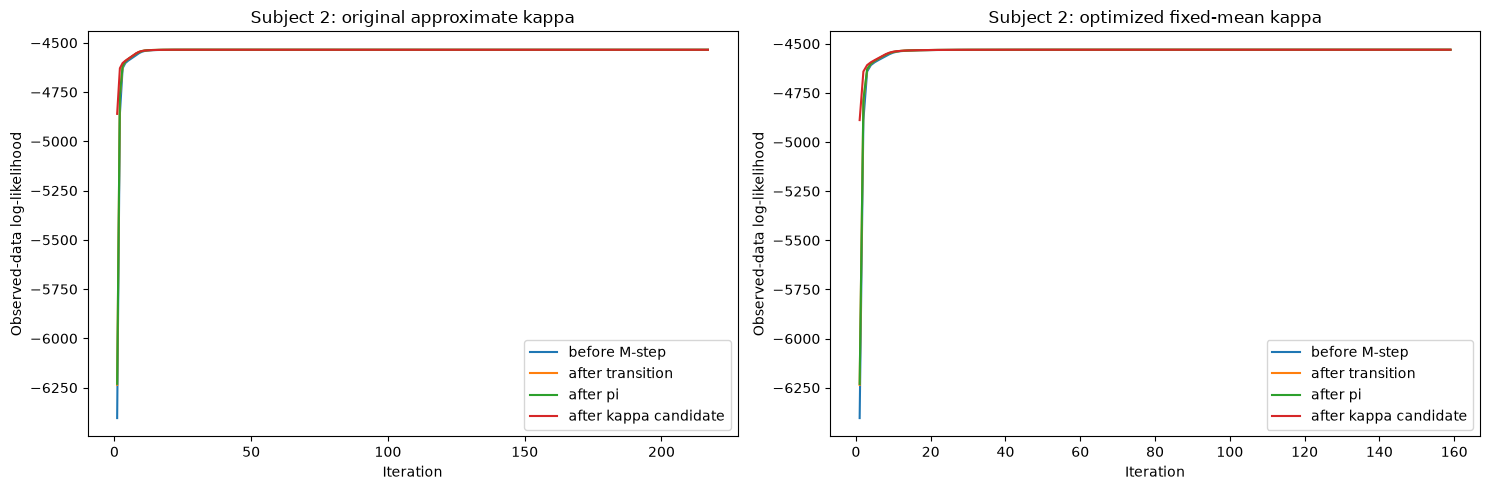

,version,transition_decreases,pi_decreases,kappa_decreases
0,approximate_kappa,0,0,107
1,optimized_kappa,0,0,0


In [34]:
approximate_diagnostic = subject2_runs["approximate_kappa"]["diagnostics"]
optimized_diagnostic = subject2_runs["optimized_kappa"]["diagnostics"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, frame, title in [
    (axes[0], approximate_diagnostic, "Subject 2: original approximate kappa"),
    (axes[1], optimized_diagnostic, "Subject 2: optimized fixed-mean kappa"),
]:
    axis.plot(frame["iteration"], frame["log_likelihood_before_m_step"], label="before M-step")
    axis.plot(frame["iteration"], frame["log_likelihood_after_transition_update"], label="after transition")
    axis.plot(frame["iteration"], frame["log_likelihood_after_pi_update"], label="after pi")
    axis.plot(frame["iteration"], frame["kappa_candidate_log_likelihood"], label="after kappa candidate")
    axis.set(xlabel="Iteration", ylabel="Observed-data log-likelihood", title=title)
    axis.legend()
fig.tight_layout()
plt.show()

decrease_diagnosis = pd.DataFrame({
    "version": ["approximate_kappa", "optimized_kappa"],
    "transition_decreases": [
        int((approximate_diagnostic["transition_step_delta"] < -likelihood_drop_tolerance).sum()),
        int((optimized_diagnostic["transition_step_delta"] < -likelihood_drop_tolerance).sum()),
    ],
    "pi_decreases": [
        int((approximate_diagnostic["pi_step_delta"] < -likelihood_drop_tolerance).sum()),
        int((optimized_diagnostic["pi_step_delta"] < -likelihood_drop_tolerance).sum()),
    ],
    "kappa_decreases": [
        int((approximate_diagnostic["kappa_step_delta"] < -likelihood_drop_tolerance).sum()),
        int((optimized_diagnostic["kappa_step_delta"] < -likelihood_drop_tolerance).sum()),
    ],
})
display(decrease_diagnosis)


## Cell H：统一修正版单被试拟合与保存函数

该函数使用缺失 trial 分段规则和 optimized fixed-mean kappa 更新，完成数值检查、Viterbi、逐被试文件保存及修正版 summary。所有被试共用同一设置。


In [35]:
def fit_subject_revised(subject_id, prepared_data, settings, max_iter):
    cleaned_df, subject_data, missing_report = prepare_subject_segments(
        subject_id, prepared_data
    )
    fit_result = fit_soft_em_hmm_diagnostic(
        data=subject_data,
        params=make_initial_params(settings),
        update_kappa=True,
        kappa_method="optimized",
        max_iter=max_iter,
        tol=settings["tol"],
        transition_smoothing=settings["transition_smoothing"],
        update_pi=settings["update_pi"],
        likelihood_drop_tolerance=settings["likelihood_drop_tolerance"],
        kappa_lower_bound=settings["kappa_lower_bound"],
        kappa_upper_bound=settings["kappa_upper_bound"],
    )
    return cleaned_df, subject_data, missing_report, fit_result


def run_revised_subject(subject_id, prepared_data, settings, output_root, max_iter):
    cleaned_df, subject_data, missing_report, fit_result = fit_subject_revised(
        subject_id, prepared_data, settings, max_iter
    )
    final_params = fit_result["params"]
    gamma = np.asarray(fit_result["gamma"], dtype=float)
    history = np.asarray(fit_result["log_likelihood_history"], dtype=float)
    differences = np.diff(history)
    transition_matrix = np.asarray(final_params["transition_matrix"], dtype=float)
    kappa_values = np.asarray(
        list(final_params["kappaS"].values()) + list(final_params["kappaP"].values()),
        dtype=float,
    )
    arrays = [gamma, history, transition_matrix, kappa_values]
    has_nan = bool(any(np.isnan(values).any() for values in arrays))
    has_inf = bool(any(np.isinf(values).any() for values in arrays))
    checks = {
        "gamma_sum": np.allclose(gamma.sum(axis=1), 1.0, atol=1e-8),
        "transition_sum": np.allclose(transition_matrix.sum(axis=1), 1.0, atol=1e-10),
        "gamma_range": np.all((gamma >= 0.0) & (gamma <= 1.0)),
        "transition_range": np.all((transition_matrix >= 0.0) & (transition_matrix <= 1.0)),
        "kappa_positive": np.all(kappa_values > 0.0),
        "finite": not has_nan and not has_inf,
    }
    if not all(bool(value) for value in checks.values()):
        raise AssertionError(f"Subject {subject_id} 数值检查失败: {checks}")

    state_names = np.array(["sensory", "prior", "lapse"])
    state_weights = gamma.mean(axis=0)
    viterbi_states = viterbi_decode_all_blocks(subject_data, final_params)
    trial_results = cleaned_df.copy()
    trial_results["x_rad"] = subject_data["x_rad"]
    trial_results["y_rad"] = subject_data["y_rad"]
    trial_results["coherence"] = subject_data["coherence"]
    trial_results["p_sensory"] = gamma[:, 0]
    trial_results["p_prior"] = gamma[:, 1]
    trial_results["p_lapse"] = gamma[:, 2]
    trial_results["most_likely_state"] = state_names[np.argmax(gamma, axis=1)]
    trial_results["viterbi_state"] = state_names[viterbi_states]

    original_subject_df = prepared_data.loc[prepared_data["subject_id"] == subject_id]
    original_n_blocks = original_subject_df.groupby(["session_id", "run_id"]).ngroups
    n_segments = int(pd.Series(subject_data["block_id"]).nunique())
    maximum_drop = float(max(0.0, -differences.min())) if len(differences) else 0.0
    summary = {
        "subject_id": int(subject_id),
        "original_n_trials": int(len(original_subject_df)),
        "removed_missing_trials": int(len(missing_report)),
        "valid_n_trials": int(len(cleaned_df)),
        "original_n_blocks": int(original_n_blocks),
        "n_segments": n_segments,
        "converged": bool(fit_result["converged"]),
        "n_iterations": int(fit_result["n_iterations"]),
        "initial_log_likelihood": float(history[0]),
        "final_log_likelihood": float(history[-1]),
        "log_likelihood_improvement": float(history[-1] - history[0]),
        "likelihood_monotonic": bool(np.all(differences >= -settings["likelihood_drop_tolerance"])),
        "maximum_likelihood_drop": maximum_drop,
        "sensory_weight": float(state_weights[0]),
        "prior_weight": float(state_weights[1]),
        "lapse_weight": float(state_weights[2]),
        "min_transition_probability": float(transition_matrix.min()),
        "max_transition_probability": float(transition_matrix.max()),
        "kappa_s_6": float(final_params["kappaS"][0.06]),
        "kappa_s_12": float(final_params["kappaS"][0.12]),
        "kappa_s_24": float(final_params["kappaS"][0.24]),
        "kappa_p_10": float(final_params["kappaP"][10]),
        "kappa_p_20": float(final_params["kappaP"][20]),
        "kappa_p_40": float(final_params["kappaP"][40]),
        "kappa_p_80": float(final_params["kappaP"][80]),
        "has_nan": has_nan,
        "has_inf": has_inf,
        "reached_max_iter": bool(not fit_result["converged"] and fit_result["n_iterations"] >= max_iter),
        "state_collapse_flag": bool(np.any(state_weights > 0.98)),
        "lapse_near_zero_flag": bool(state_weights[2] < 0.005),
        "transition_near_smoothing_floor_flag": bool(transition_matrix.min() <= 1e-6),
    }

    subject_output = output_root / f"subject_{int(subject_id):02d}"
    subject_output.mkdir(parents=True, exist_ok=True)
    trial_columns = [
        "subject_id", "session_id", "run_id", "block_id", "trial_index",
        "x_rad", "y_rad", "coherence", "prior_std", "p_sensory",
        "p_prior", "p_lapse", "most_likely_state", "viterbi_state",
    ]
    trial_results[trial_columns].to_csv(
        subject_output / f"subject_{int(subject_id):02d}_trial_posteriors.csv", index=False
    )
    pd.DataFrame({
        "iteration": np.arange(len(history)),
        "log_likelihood": history,
    }).to_csv(
        subject_output / f"subject_{int(subject_id):02d}_log_likelihood_history.csv",
        index=False,
    )
    parameter_payload = {
        **summary,
        "pi": final_params["initial_prob"].tolist(),
        "transition_matrix": transition_matrix.tolist(),
        "sensory_kappas": {str(key): float(value) for key, value in final_params["kappaS"].items()},
        "prior_kappas": {str(key): float(value) for key, value in final_params["kappaP"].items()},
        "training_settings": {**settings, "max_iter": max_iter},
    }
    with (subject_output / f"subject_{int(subject_id):02d}_parameters.json").open(
        "w", encoding="utf-8"
    ) as handle:
        json.dump(parameter_payload, handle, ensure_ascii=False, indent=2)

    transition_record = {"subject_id": int(subject_id)}
    for previous_index, previous_name in enumerate(state_names):
        for next_index, next_name in enumerate(state_names):
            transition_record[f"{previous_name}_to_{next_name}"] = float(
                transition_matrix[previous_index, next_index]
            )
    return summary, missing_report, transition_record, fit_result


## Cell I：验证 Subject 4 和 10 的缺失断点规则

先单独使用修正版拟合 Subject 4 和 10，输出原始/删除/有效 trial、原始 block、segment 数、收敛和 state weights；不填补 response，也不连接缺失前后的 transition。


In [36]:
missing_validation_rows = []
missing_validation_reports = []
for missing_subject_id in [4, 10]:
    cleaned_df, subject_data, missing_report, fit_result = fit_subject_revised(
        missing_subject_id, prepared_data, training_settings, base_max_iter
    )
    weights = fit_result["gamma"].mean(axis=0)
    history = np.asarray(fit_result["log_likelihood_history"], dtype=float)
    original_frame = prepared_data.loc[prepared_data["subject_id"] == missing_subject_id]
    missing_validation_rows.append({
        "subject_id": missing_subject_id,
        "original_n_trials": len(original_frame),
        "removed_missing_trials": len(missing_report),
        "valid_n_trials": len(cleaned_df),
        "original_n_blocks": original_frame.groupby(["session_id", "run_id"]).ngroups,
        "n_segments": pd.Series(subject_data["block_id"]).nunique(),
        "converged": fit_result["converged"],
        "n_iterations": fit_result["n_iterations"],
        "final_log_likelihood": history[-1],
        "sensory_weight": weights[0],
        "prior_weight": weights[1],
        "lapse_weight": weights[2],
    })
    missing_validation_reports.append(missing_report)

missing_validation = pd.DataFrame(missing_validation_rows)
missing_positions = pd.concat(missing_validation_reports, ignore_index=True)
display(missing_validation)
display(missing_positions)


,subject_id,original_n_trials,removed_missing_trials,valid_n_trials,original_n_blocks,n_segments,converged,n_iterations,final_log_likelihood,sensory_weight,prior_weight,lapse_weight
0,4,4801,2,4799,23,23,True,67,-3710.762561,0.471146,0.491111,0.037743
1,10,6045,1,6044,29,28,False,300,-6171.029491,0.447894,0.444290,0.107815


,subject_id,session_id,run_id,trial_index,original_row_index,original_block_id,estimate_x_missing,estimate_y_missing,preceding_valid_trial_index,following_valid_trial_index
0,4,5,20,146,30043,5_20,True,True,145.0,NaN
1,4,5,23,188,30651,5_23,True,True,187.0,NaN
2,10,3,12,1,66604,3_12,True,True,NaN,NaN


## Cell J：重新检查原未收敛被试

先统一用 `max_iter=300` 重跑 Subject 3、5、9、11，并检查最后 20 次 likelihood、transition 和 kappa 变化。如果仍未收敛但 likelihood 在 `1e-8` 容差内稳定不下降，则统一把最终全被试上限提高到 600。


In [37]:
previously_nonconverged = [3, 5, 9, 11]
nonconverged_checks = []
check_results_300 = {}

for check_subject_id in previously_nonconverged:
    cleaned_df, subject_data, missing_report, fit_result = fit_subject_revised(
        check_subject_id, prepared_data, training_settings, base_max_iter
    )
    check_results_300[check_subject_id] = fit_result
    history = np.asarray(fit_result["log_likelihood_history"], dtype=float)
    last_differences = np.diff(history[-21:])
    last_diagnostics = fit_result["diagnostics"].tail(20)
    nonconverged_checks.append({
        "subject_id": check_subject_id,
        "converged_at_300": fit_result["converged"],
        "n_iterations": fit_result["n_iterations"],
        "last20_min_likelihood_change": float(last_differences.min()),
        "last20_max_likelihood_change": float(last_differences.max()),
        "last20_max_transition_change": float(last_diagnostics["maximum_change_in_transition"].max()),
        "last20_max_kappa_change": float(last_diagnostics["maximum_change_in_kappa"].max()),
    })

nonconverged_check_table = pd.DataFrame(nonconverged_checks)
still_nonconverged = nonconverged_check_table.loc[
    ~nonconverged_check_table["converged_at_300"], "subject_id"
].astype(int).tolist()
stable_nonconverged = nonconverged_check_table.loc[
    (~nonconverged_check_table["converged_at_300"])
    & (nonconverged_check_table["last20_min_likelihood_change"] >= -likelihood_drop_tolerance),
    "subject_id",
].astype(int).tolist()

use_extended_max_iter = bool(still_nonconverged) and set(still_nonconverged) == set(stable_nonconverged)
final_max_iter = 600 if use_extended_max_iter else 300
display(nonconverged_check_table)
print("still_nonconverged_at_300:", still_nonconverged)
print("stable_nonconverged_at_300:", stable_nonconverged)
print("final_uniform_max_iter:", final_max_iter)

check_results_extended = {}
if use_extended_max_iter:
    for check_subject_id in previously_nonconverged:
        *_, extended_result = fit_subject_revised(
            check_subject_id, prepared_data, training_settings, final_max_iter
        )
        check_results_extended[check_subject_id] = extended_result
    extended_table = pd.DataFrame([
        {
            "subject_id": subject_id,
            "converged": result["converged"],
            "n_iterations": result["n_iterations"],
            "final_log_likelihood": result["log_likelihood_history"][-1],
        }
        for subject_id, result in check_results_extended.items()
    ])
    display(extended_table)


,subject_id,converged_at_300,n_iterations,last20_min_likelihood_change,last20_max_likelihood_change,last20_max_transition_change,last20_max_kappa_change
0,3,True,120,9.441319e-07,0.000007,0.000005,0.002714
1,5,False,300,1.165263e-05,0.000015,0.000038,0.014453
2,9,True,199,9.663208e-07,0.000004,0.000011,0.000324
3,11,True,74,9.053065e-07,0.000012,0.000073,0.000318


still_nonconverged_at_300: [5]
stable_nonconverged_at_300: [5]
final_uniform_max_iter: 600


,subject_id,converged,n_iterations,final_log_likelihood
0,3,True,120,-4406.830632
1,5,True,592,-7395.507989
2,9,True,199,-7422.517679
3,11,True,74,-5327.506020


## Cell K：用统一修正版重新运行全部 12 名被试

在 Subject 2、缺失断点和未收敛检查完成后，使用同一 kappa 修正和统一 `final_max_iter` 运行全部被试。每名被试独立拟合和保存，失败时写入新失败记录并继续。


In [38]:
revised_summaries = []
revised_failures = []
revised_missing_reports = []
revised_transition_records = []

for subject_id in subject_ids:
    try:
        summary, missing_report, transition_record, fit_result = run_revised_subject(
            int(subject_id),
            prepared_data,
            training_settings,
            output_root,
            final_max_iter,
        )
        revised_summaries.append(summary)
        revised_transition_records.append(transition_record)
        if not missing_report.empty:
            revised_missing_reports.append(missing_report)
        print(
            f"Subject {int(subject_id):02d}: success; converged={summary['converged']}; "
            f"iterations={summary['n_iterations']}; monotonic={summary['likelihood_monotonic']}"
        )
    except Exception as error:
        revised_failures.append({
            "subject_id": int(subject_id),
            "error_type": type(error).__name__,
            "error_message": str(error),
            "stage": "revised_full_run",
        })
        print(f"Subject {int(subject_id):02d}: failed - {type(error).__name__}: {error}")

all_subject_summary_revised = pd.DataFrame(revised_summaries).sort_values("subject_id")
failed_subjects_revised = pd.DataFrame(
    revised_failures,
    columns=["subject_id", "error_type", "error_message", "stage"],
)
all_subject_transition_matrices_revised = pd.DataFrame(
    revised_transition_records
).sort_values("subject_id")
missing_trial_report = (
    pd.concat(revised_missing_reports, ignore_index=True)
    if revised_missing_reports
    else pd.DataFrame(columns=missing_positions.columns)
)

all_subject_summary_revised.to_csv(
    output_root / "all_subject_summary_revised.csv", index=False
)
failed_subjects_revised.to_csv(
    output_root / "failed_subjects_revised.csv", index=False
)
all_subject_transition_matrices_revised.to_csv(
    output_root / "all_subject_transition_matrices_revised.csv", index=False
)
missing_trial_report.to_csv(output_root / "missing_trial_report.csv", index=False)


Subject 01: success; converged=True; iterations=232; monotonic=True


Subject 02: success; converged=True; iterations=159; monotonic=True


Subject 03: success; converged=True; iterations=120; monotonic=True


Subject 04: success; converged=True; iterations=67; monotonic=True


Subject 05: success; converged=True; iterations=592; monotonic=True


...

Subject 08: success; converged=True; iterations=221; monotonic=True


Subject 09: success; converged=True; iterations=199; monotonic=True


Subject 10: success; converged=False; iterations=600; monotonic=True


Subject 11: success; converged=True; iterations=74; monotonic=True


Subject 12: success; converged=True; iterations=138; monotonic=True


## Cell L：最终数值与文件检查

汇总成功、收敛、monotonicity、NaN/Inf、state collapse 和输出文件存在性，并显示缺失 trial 报告及修正版 summary。


In [39]:
missing_output_files = []
for subject_id in all_subject_summary_revised["subject_id"].astype(int):
    subject_output = output_root / f"subject_{subject_id:02d}"
    expected = [
        subject_output / f"subject_{subject_id:02d}_parameters.json",
        subject_output / f"subject_{subject_id:02d}_trial_posteriors.csv",
        subject_output / f"subject_{subject_id:02d}_log_likelihood_history.csv",
    ]
    missing_output_files.extend(str(path) for path in expected if not path.exists())
if missing_output_files:
    raise AssertionError(f"缺少结果文件: {missing_output_files}")

final_report = {
    "total_subjects": len(subject_ids),
    "successful_subjects": len(all_subject_summary_revised),
    "failed_subjects": len(failed_subjects_revised),
    "converged_subjects": int(all_subject_summary_revised["converged"].sum()),
    "nonconverged_subjects": all_subject_summary_revised.loc[
        ~all_subject_summary_revised["converged"], "subject_id"
    ].astype(int).tolist(),
    "nonmonotonic_subjects": all_subject_summary_revised.loc[
        ~all_subject_summary_revised["likelihood_monotonic"], "subject_id"
    ].astype(int).tolist(),
    "nan_or_inf_subjects": all_subject_summary_revised.loc[
        all_subject_summary_revised["has_nan"] | all_subject_summary_revised["has_inf"],
        "subject_id",
    ].astype(int).tolist(),
    "state_collapse_subjects": all_subject_summary_revised.loc[
        all_subject_summary_revised["state_collapse_flag"], "subject_id"
    ].astype(int).tolist(),
    "lapse_near_zero_subjects": all_subject_summary_revised.loc[
        all_subject_summary_revised["lapse_near_zero_flag"], "subject_id"
    ].astype(int).tolist(),
    "transition_near_floor_subjects": all_subject_summary_revised.loc[
        all_subject_summary_revised["transition_near_smoothing_floor_flag"], "subject_id"
    ].astype(int).tolist(),
    "removed_missing_trials": int(all_subject_summary_revised["removed_missing_trials"].sum()),
    "all_output_files_exist": not missing_output_files,
    "final_uniform_max_iter": final_max_iter,
}
display(pd.Series(final_report, name="value").to_frame())
display(all_subject_summary_revised)
display(missing_trial_report)
display(failed_subjects_revised)


,value
total_subjects,12
successful_subjects,12
failed_subjects,0
converged_subjects,11
nonconverged_subjects,[10]
nonmonotonic_subjects,[]
nan_or_inf_subjects,[]
state_collapse_subjects,[]
lapse_near_zero_subjects,[]
transition_near_floor_subjects,"[1, 2, 3, 4, 5, 6, 7, 8, 9]"


,subject_id,original_n_trials,removed_missing_trials,valid_n_trials,original_n_blocks,n_segments,converged,n_iterations,initial_log_likelihood,final_log_likelihood,...,kappa_p_10,kappa_p_20,kappa_p_40,kappa_p_80,has_nan,has_inf,reached_max_iter,state_collapse_flag,lapse_near_zero_flag,transition_near_smoothing_floor_flag
0,1,8562,0,8562,40,40,True,232,-5571.043506,-3932.074763,...,116.114882,45.454706,17.022476,1.223277,False,False,False,False,False,True
1,2,7877,0,7877,37,37,True,159,-6404.258575,-4530.386691,...,69.491162,33.071744,9.924567,2.650517,False,False,False,False,False,True
2,3,9412,0,9412,44,44,True,120,-5978.304504,-4406.830632,...,28.262685,15.732667,10.084456,14.775515,False,False,False,False,False,True
3,4,4801,2,4799,23,23,True,67,-4195.211881,-3710.762561,...,20.615246,12.076466,6.147561,2.330970,False,False,False,False,False,True
4,5,5789,0,5789,27,27,True,592,-8050.280752,-7395.507989,...,137.721533,0.000001,0.334358,0.000001,False,False,False,False,False,True
5,6,7553,0,7553,35,35,True,116,-7510.431916,-6867.344571,...,10.760166,7.941498,4.531842,0.000001,False,False,False,False,False,True
6,7,5797,0,5797,27,27,True,83,-4360.677745,-3748.090897,...,27.126178,11.960029,10.811109,1.217740,False,False,False,False,False,True
7,8,5797,0,5797,27,27,True,221,-7692.273051,-7107.878243,...,7.714289,4.102699,3.398583,2.153756,False,False,False,False,False,True
8,9,8632,0,8632,40,40,True,199,-7998.004869,-7422.517679,...,13.913749,11.694574,9.816863,7.380686,False,False,False,False,False,True
9,10,6045,1,6044,29,28,False,600,-6638.741460,-6170.839704,...,17.545675,16.122042,7.500724,0.396890,False,False,True,False,False,False


,subject_id,session_id,run_id,trial_index,original_row_index,original_block_id,estimate_x_missing,estimate_y_missing,preceding_valid_trial_index,following_valid_trial_index
0,4,5,20,146,30043,5_20,True,True,145.0,NaN
1,4,5,23,188,30651,5_23,True,True,187.0,NaN
2,10,3,12,1,66604,3_12,True,True,NaN,NaN


,subject_id,error_type,error_message,stage


## Cell M：必要的修正版质量检查图

仅绘制各被试 state weights、最终 likelihood 和迭代次数；Subject 2 的分步骤 likelihood 图已在诊断部分给出。


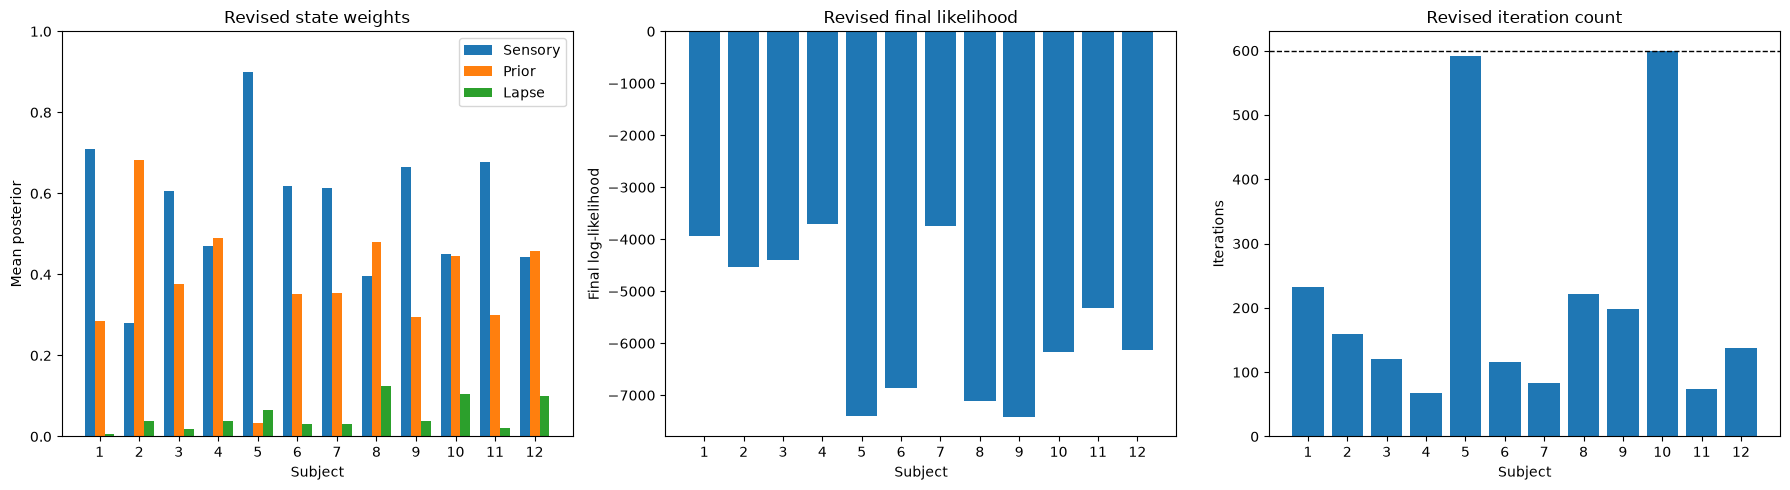

In [40]:
plot_table = all_subject_summary_revised.sort_values("subject_id")
plot_subjects = plot_table["subject_id"].astype(int).to_numpy()
x = np.arange(len(plot_subjects))
width = 0.25
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].bar(x - width, plot_table["sensory_weight"], width, label="Sensory")
axes[0].bar(x, plot_table["prior_weight"], width, label="Prior")
axes[0].bar(x + width, plot_table["lapse_weight"], width, label="Lapse")
axes[0].set_xticks(x, plot_subjects)
axes[0].set(xlabel="Subject", ylabel="Mean posterior", title="Revised state weights", ylim=(0, 1))
axes[0].legend()
axes[1].bar(plot_subjects.astype(str), plot_table["final_log_likelihood"])
axes[1].set(xlabel="Subject", ylabel="Final log-likelihood", title="Revised final likelihood")
axes[2].bar(plot_subjects.astype(str), plot_table["n_iterations"])
axes[2].axhline(final_max_iter, color="black", linestyle="--", linewidth=1)
axes[2].set(xlabel="Subject", ylabel="Iterations", title="Revised iteration count")
fig.tight_layout()
plt.show()
